# Performance Testing

## Requirements

1. *aiohttp* for asynchronous HTTP calls
2. *asyncio* for concurrency control
3. *tqdm* (optional) for a progress bar

In [1]:
import asyncio
import aiohttp
import time
from itertools import cycle
from tqdm import tqdm
import nest_asyncio

import csv
import matplotlib.pyplot as plt
import pandas as pd


# Allow asyncio.run / new loops in Jupyter
nest_asyncio.apply()


In [2]:
# Target endpoints
URLS = [
    "http://127.0.0.1:8086/unibe/portal/microsites/micro_teachinghub/content/++rest_api/e1701267%2Fe1728866/get_child_nodes",
    "http://127.0.0.1:8086/unibe/portal/microsites/micro_teachinghub/content/++rest_api/e1701267%2Fe1728866/get_body_content"
]

# Number of requests _per_ URL and concurrency
REQUESTS_PER_URL = 100
CONCURRENCY = 12

In [3]:
# Core Async Functions
async def fetch(session: aiohttp.ClientSession, url: str) -> float:
    """Send GET and return elapsed seconds."""
    start = time.monotonic()
    async with session.get(url) as resp:
        await resp.read()
    return time.monotonic() - start

async def bound_fetch(sem, session, url, latencies):
    """Semaphore‐guarded fetch that appends to latencies."""
    async with sem:
        try:
            lat = await fetch(session, url)
            latencies.append(lat)
        except Exception as e:
            latencies.append(None)
            print(f"Error fetching {url}: {e}")


In [4]:
# Runner Coroutine
async def run_test():
    sem = asyncio.Semaphore(CONCURRENCY)
    latencies = []
    total_calls = REQUESTS_PER_URL * len(URLS)

    async with aiohttp.ClientSession() as session:
        tasks = [
            bound_fetch(sem, session, next(cycle(URLS)), latencies)
            for _ in range(total_calls)
        ]
        for task in tqdm(asyncio.as_completed(tasks), total=total_calls):
            await task

    # compute metrics
    success = [l for l in latencies if l is not None]
    stats = {
        "total": len(latencies),
        "succeeded": len(success),
        "failed": len(latencies) - len(success),
        "avg_s": sum(success) / len(success),
        "min_s": min(success),
        "max_s": max(success),
        "throughput_rps": len(success) / sum(success),
    }

    return stats, latencies


In [5]:
# Execute benchmark
start = time.monotonic()
results, latencies = await run_test()
wall = time.monotonic() - start

# Print summary
from pprint import pprint
pprint(results)
print(f"Total wall time: {wall:.2f}s")


100%|██████████| 200/200 [00:23<00:00,  8.36it/s]

{'avg_s': 1.3985677326699988,
 'failed': 0,
 'max_s': 1.9670146019998356,
 'min_s': 0.20342647900179145,
 'succeeded': 200,
 'throughput_rps': 0.715017211280075,
 'total': 200}
Total wall time: 24.00s


In [6]:
# Cell: Persist latencies
df = pd.DataFrame(latencies, columns=["latency_s"])
csv_path = "performance_results.csv"
df.to_csv(csv_path, index=False)

print(f"Saved {len(df)} records to {csv_path}")


Saved 200 records to performance_results.csv


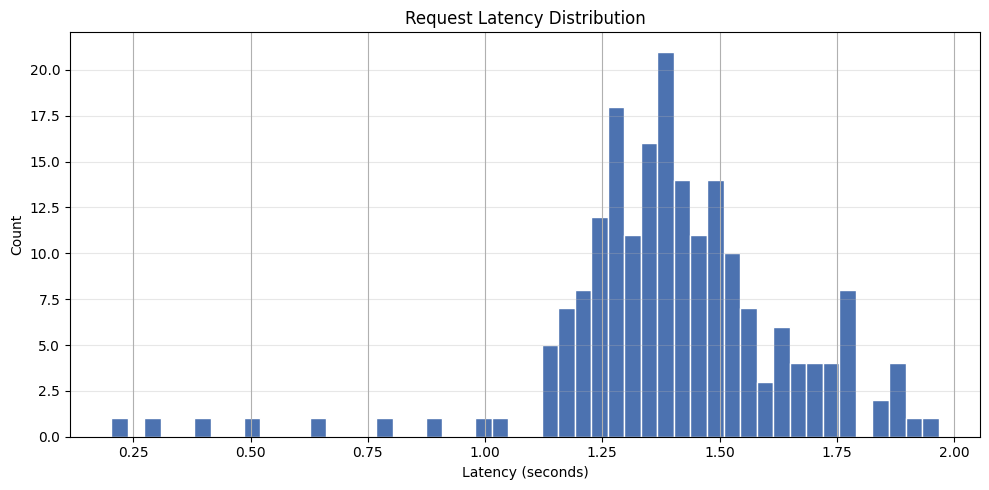

        latency_s
count  200.000000
mean     1.398568
std      0.252421
min      0.203426
25%      1.279038
50%      1.392428
75%      1.516408
max      1.967015


In [7]:
# Cell: Display histogram
%matplotlib inline

plt.figure(figsize=(10, 5))
df["latency_s"].hist(bins=50, color="#4C72B0", edgecolor="white")
plt.title("Request Latency Distribution")
plt.xlabel("Latency (seconds)")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(df.describe())